In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nathaniellybrand/chicago-crime-dataset-2001-present/Crimes_-_2001_to_Present.csv


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files)

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/nathaniellybrand
[]
/kaggle/input/datasets/nathaniellybrand/chicago-crime-dataset-2001-present
['Crimes_-_2001_to_Present.csv']


In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [7]:
for root, dirs, files in os.walk("/kaggle/input"):
    print("ROOT:", root)
    print("FILES:", files)

ROOT: /kaggle/input
FILES: []
ROOT: /kaggle/input/datasets
FILES: []
ROOT: /kaggle/input/datasets/nathaniellybrand
FILES: []
ROOT: /kaggle/input/datasets/nathaniellybrand/chicago-crime-dataset-2001-present
FILES: ['Crimes_-_2001_to_Present.csv']


In [1]:
import pandas as pd
import os

file_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)

#LOAD ONLY 50,000 ROWS
df = pd.read_csv(file_path, nrows=50000)

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN


In [3]:
# Convert Date
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')

# Drop missing values
df = df.dropna(subset=["Primary Type", "Date", "Location Description"])

# Create new columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [ ]:
import matplotlib.pyplot as plt

df["Primary Type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.show()

df["Year"].value_counts().sort_index().plot()
plt.title("Crime Trend Over Years")
plt.show()

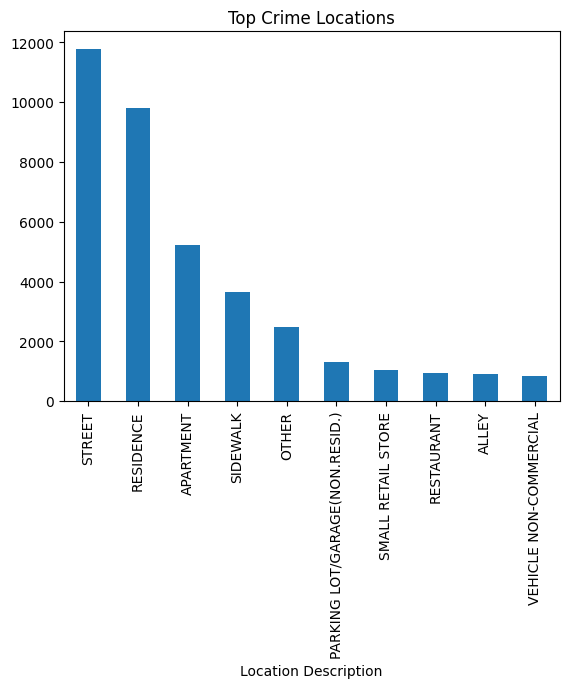

In [6]:
df["Location Description"].value_counts().head(10).plot(kind="bar")
plt.title("Top Crime Locations")
plt.show()

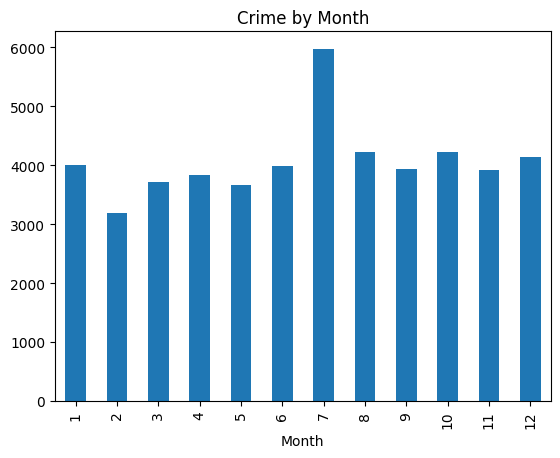

In [7]:
df["Month"].value_counts().sort_index().plot(kind="bar")
plt.title("Crime by Month")
plt.show()

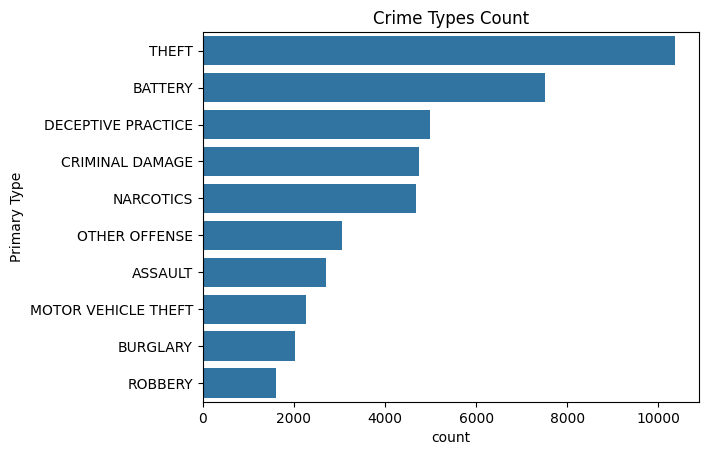

In [8]:
import seaborn as sns

sns.countplot(y=df["Primary Type"], order=df["Primary Type"].value_counts().index[:10])
plt.title("Crime Types Count")
plt.show()